# **ENUNCIADO**

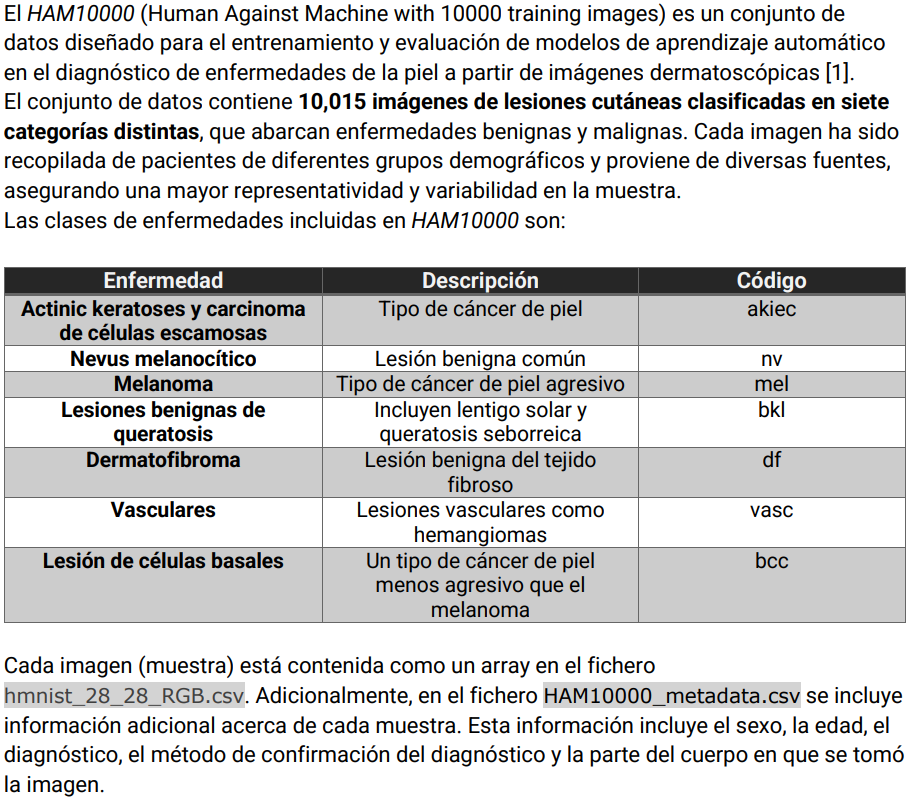

## **TAREA**

Se propone que el alumno diseñe, implemente y evalúe diferentes modelos predictivos basados en redes neuronales profundas de cara a resolver el problema de clasificación multiclase propuesto.

### 0 - Carga y preprocesamiento de datos

In [1]:
!rm -f HAM10000_metadata.csv* hmnist_28_28_RGB.csv*
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -f HAM10000_metadata.csv --force
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -f hmnist_28_28_RGB.csv --force
!unzip -o HAM10000_metadata.csv.zip 2>/dev/null || echo 'ya descomprimido'
!unzip -o hmnist_28_28_RGB.csv.zip 2>/dev/null || echo 'ya descomprimido'

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 550k/550k [00:01<00:00, 484kB/s]

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 26.2M/26.2M [00:02<00:00, 9.53MB/s]

ya descomprimido
Archive:  hmnist_28_28_RGB.csv.zip
  inflating: hmnist_28_28_RGB.csv    


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Flatten, Dropout, Conv2D, BatchNormalization, Activation, GlobalMaxPooling2D, Concatenate, GlobalAveragePooling2D, Resizing, Lambda, Add)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import plot_model
import urllib
import cv2

In [3]:
# --- Carga de los CSV ---
df_metadata = pd.read_csv('HAM10000_metadata.csv')
df_rgb = pd.read_csv('hmnist_28_28_RGB.csv')

print('df_metadata:', df_metadata.shape)
# Los 2353, son los 28x28x3
print('df_rgb:', df_rgb.shape)
print(df_metadata.head(1))
print(df_rgb.head(1))

df_metadata: (10015, 7)
df_rgb: (10015, 2353)
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
   pixel0000  pixel0001  pixel0002  pixel0003  pixel0004  pixel0005  \
0        192        153        193        195        155        192   

   pixel0006  pixel0007  pixel0008  pixel0009  ...  pixel2343  pixel2344  \
0        197        154        185        202  ...        173        124   

   pixel2345  pixel2346  pixel2347  pixel2348  pixel2349  pixel2350  \
0        138        183        147        166        185        154   

   pixel2351  label  
0        177      2  

[1 rows x 2353 columns]


In [4]:
# Preprocesado de los datos tabulares
df = df_metadata.copy()
df['age'] = df['age'].fillna(df['age'].median())
df['age'] = df['age'] / 100.0  # normalización a rango [0,1]

# One-hot encoding de variables categóricas con pandas
df_tab = pd.get_dummies(df[['sex', 'localization']], drop_first=False)
df_tab['age'] = df['age'].values

# X_tab, es una representación numérica de los datos procesados.
# Es un array de numpy que contiene:
#   - Las columnas de one-hot encoding para 'sex' (sex_female, sex_male, sex_unknown).
#   - Las columnas de one-hot encoding para 'localization' (las diferentes partes del cuerpo).
#   - La columna de 'age' normalizada.
X_tab = df_tab.values.astype(np.float32)
print('X_tab.shape:', X_tab.shape)

X_tab.shape: (10015, 19)


In [5]:
# HE IDO SIGUIENDO LA LÓGICA DEL EJERCICIO DESARROLLADO A TRAVES DE UN DATASET
# REAL EN KAGGLE EN EL NOTEBOOK DE FUSION
# Creamos la lista classes:
# Con (df['dx'].unique()), seleccionamos los datos unicos de la columna dx de df.
# Con sorted, los ordenamos alfabeticamente.
classes = sorted(df['dx'].unique())
# Generamos el diccionario class_to_idx asignado un numero, empezando desde 0,
# a cada una de las clases incluidas en la lista classes.
class_to_idx = {c: i for i, c in enumerate(classes)}
# Generamos y_int donde la función .map, mira el valor de df['dx'], busca en el
# diccionario la equivalencia numérica, y la sustituye.
y_int = df['dx'].map(class_to_idx).values.astype('int32')
n_classes = len(classes)
# Lo pasamos a categorico
Y = to_categorical(y_int, num_classes=n_classes)
print('Clases:', classes)
print("class_to_idx", class_to_idx)
print("y_int", y_int)
print('Y.shape:', Y.shape, ' (one-hot)')

Clases: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
class_to_idx {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
y_int [2 2 2 ... 0 0 4]
Y.shape: (10015, 7)  (one-hot)


X_img.shape: (10015, 28, 28, 3) | rango: 0.0 - 255.0


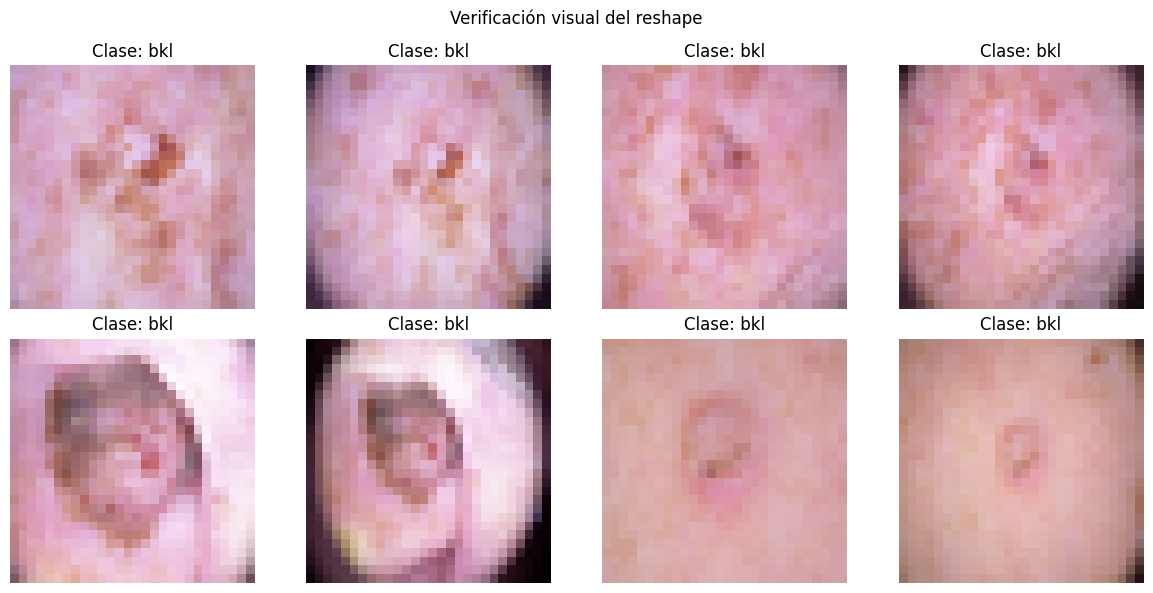

In [6]:
# Preprocesamiento de imágenes
# df_rgb, tiene una columna label, la cual ya hemos procesado anteriormente.
# la quitamos
X_img_label = df_rgb.drop(columns='label').values
# Ahora hacemos el reshape
X_img = X_img_label.reshape(-1, 28, 28, 3).astype(np.float32)

print('X_img.shape:', X_img.shape, '| rango:', X_img.min(), '-', X_img.max())

# Verificación visual (crítica: si el reshape está mal, se ven ruido)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_img[i]/255.0)
    ax.set_title(f'Clase: {classes[y_int[i]]}')
    ax.axis('off')
plt.suptitle('Verificación visual del reshape')
plt.tight_layout()
plt.show()

In [7]:
# --- Split ÚNICO por índices (para alinear tabular, imagen y etiqueta) ---
# Con indices, genero un array de numpy el cual contiene una secuencia de números
# enteros de 0 a ley(Y) - 1

indices = np.arange(len(Y))

# El utilizar indices como referencia, hace que tanto el train, val y test para
# los datos tabulares y las imágenes, sean consistentes y que no se dividan de
# dos maneras diferentes para cada tipo de dato.
idx_train, idx_test = train_test_split(indices, test_size=0.2, stratify=y_int, random_state=42)
idx_train, idx_val = train_test_split(idx_train, test_size=0.2, stratify=y_int[idx_train], random_state=42)

X_tab_train, X_tab_val, X_tab_test = X_tab[idx_train], X_tab[idx_val], X_tab[idx_test]
X_img_train, X_img_val, X_img_test = X_img[idx_train], X_img[idx_val], X_img[idx_test]

# Contiene las etiquetas one-hoy encoded
# Esto es un vector binario (por ejemplo, [0, 0, 1, 0, 0, 0, 0] para la clase 2).
Y_train, Y_val, Y_test = Y[idx_train], Y[idx_val], Y[idx_test]
# Contiene las etiquetas en formato entero
# (por ejemplo, 2 para la clase 2)
y_train_int, y_val_int, y_test_int = y_int[idx_train], y_int[idx_val], y_int[idx_test]

print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')
print(len(idx_train)+len(idx_val)+len(idx_test))

Train: 6409 | Val: 1603 | Test: 2003
10015


### 1 - Modelo 1D (tabular): Resolver el problema considerando únicamente la información presente en los datos tabulares (sexo, edad, parte del cuerpo).

In [8]:
# Construyo la Red Neuronal para los datos tabulares
# Uso la API funcional
tab_in = Input(shape=(X_tab_train.shape[1],))
h0 = Dense(32, activation='relu')(tab_in)
h1 = Dense(32, activation='selu')(h0)
h2 = Dense(16, activation='relu')(h1)
h3 = Dense(16, activation='selu', name = "tabular_features")(h2)
tab_out = Dense(n_classes, activation='softmax')(h3)
tabular_model = Model(inputs=tab_in, outputs=tab_out)
tabular_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 19)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tabular_features (Dense)        │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,615 (10.21 KB)

 Trainable params: 2,615 (10.21 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#Definición de hiperparámetros
lr = 0.001
epoches = 35
batch = 16

In [10]:
optimizer = Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)
tabular_model.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])

In [11]:
H_tab = tabular_model.fit(X_tab_train, Y_train, validation_data=(X_tab_val, Y_val), epochs=epoches, batch_size=batch)

Epoch 1/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6706 - loss: 1.0706 - val_accuracy: 0.7006 - val_loss: 0.9296
Epoch 2/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6951 - loss: 0.9362 - val_accuracy: 0.7024 - val_loss: 0.9089
Epoch 3/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6976 - loss: 0.9268 - val_accuracy: 0.6993 - val_loss: 0.8973
Epoch 4/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6971 - loss: 0.9184 - val_accuracy: 0.7049 - val_loss: 0.9014
Epoch 5/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6956 - loss: 0.9143 - val_accuracy: 0.7062 - val_loss: 0.8937
Epoch 6/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6954 - loss: 0.9083 - val_accuracy: 0.7043 - val_loss: 0.8920
Epoch 7/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6970 - loss: 0.9074 - val_accuracy: 0.7037 - val_loss: 0.8894
Epoch 8/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6970 - loss: 0.9057 - val_accuracy: 0.

In [12]:
pred = tabular_model.predict(X_tab_val)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


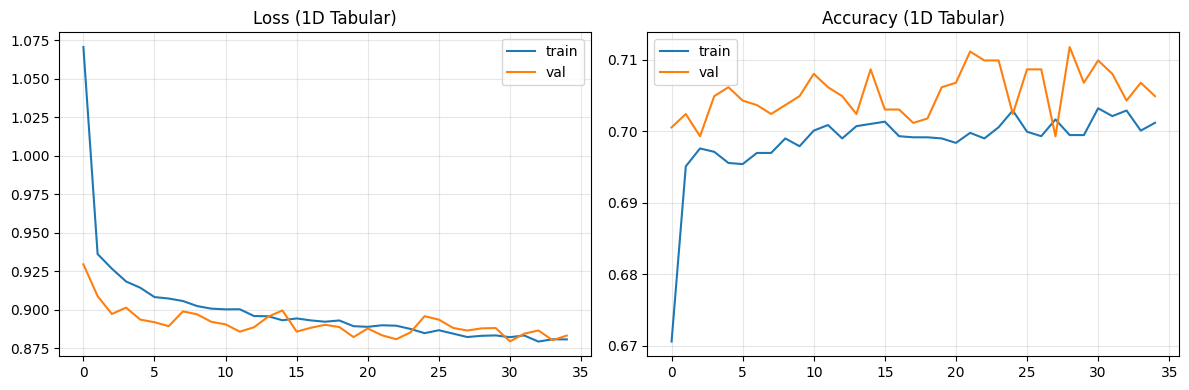

In [13]:
# Dibujo las curvas de entrenamiento para Loss y Accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_tab.history['loss'], label='train')
axes[0].plot(H_tab.history['val_loss'], label='val')
axes[0].set_title('Loss (1D Tabular)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(H_tab.history['accuracy'], label='train')
axes[1].plot(H_tab.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy (1D Tabular)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 2 - Modelo 2D (imágenes): Resolver el problema considerando la información presente en las imágenes empleando para ello al menos una red convolucional.

In [14]:
mean_per_channel = (X_img_train/255).mean(axis=(0, 1, 2))

In [15]:
dropout_rate = 0.5

img_in = Input(shape=(28, 28, 3), name='img_in')
x = img_in/255
# Usamos una capa Lambda para aplicar la resta de la media
x = Lambda(lambda image: image - mean_per_channel)(x)
x = Conv2D(32, kernel_size=(3, 3))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(64, kernel_size=(3, 3))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = GlobalMaxPooling2D()(x)
x = Flatten()(x)

x = Dense(1024, activation='relu', name = "vision_features")(x)
x = Dropout(dropout_rate)(x)

img_out = Dense(n_classes, activation='softmax', name='vision_output')(x)
vision_model_1 = Model(inputs=img_in, outputs=img_out)
vision_model_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img_in (InputLayer)             │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vision_features (Dense)         │ (None, 1024)           │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vision_output (Dense)           │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,511 (365.28 KB)

 Trainable params: 93,319 (364.53 KB)

 Non-trainable params: 192 (768.00 B)

In [16]:
#Definición de hiperparámetros
lr = 0.001
epoches = 35
batch = 16

In [17]:
optimizer = Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)

In [18]:
vision_model_1.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
H_vis_1 = vision_model_1.fit(X_img_train, Y_train, validation_data=(X_img_val, Y_val), epochs=epoches, batch_size=batch)

Epoch 1/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6599 - loss: 0.9909 - val_accuracy: 0.5128 - val_loss: 1.2285
Epoch 2/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6828 - loss: 0.8488 - val_accuracy: 0.6669 - val_loss: 0.9689
Epoch 3/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7020 - loss: 0.7985 - val_accuracy: 0.7243 - val_loss: 0.7370
Epoch 4/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7120 - loss: 0.7726 - val_accuracy: 0.7293 - val_loss: 0.7105
Epoch 5/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7213 - loss: 0.7571 - val_accuracy: 0.7405 - val_loss: 0.6879
Epoch 6/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7213 - loss: 0.7386 - val_accuracy: 0.7386 - val_loss: 0.7097
Epoch 7/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7293 - loss: 0.7155 - val_accuracy: 0.7567 - val_loss: 0.6844
Epoch 8/35
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7351 - loss: 0.7150 - val_accuracy: 

In [20]:
pred_1 = vision_model_1.predict(X_img_val)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


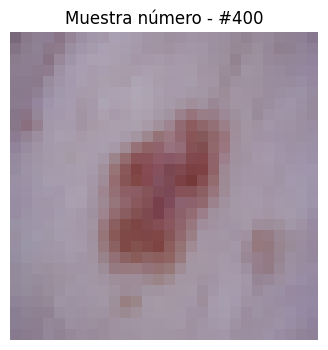

El modelo predice: nv
En realidad es:    nv


In [21]:
#HAGO UN COMPROBADOR (similar al que hay en el notebook del tema 3)

#Indico el índice para identificar la muestra
idx = 400

# Saco el vector de 7 probabilidades que el modelo asignó a idx
pred_probs = pred[idx]
# Saco el índice con el valor más alto (devuelve un nº entero)
pred_class_idx = np.argmax(pred_probs)
# Con ese entero, me voy a classes y saco el valor en texto.
pred_class_name = classes[pred_class_idx]

# La misma lógica para el conjunto de validación
true_class_idx = y_val_int[idx]
true_class_name = classes[true_class_idx]

# 3) Mostramos la imagen primero (sin título de predicción)
plt.figure(figsize=(4, 4))
plt.imshow(X_img_val[idx] / 255.0)

plt.title(f"Muestra número - #{idx}")
plt.axis('off')
plt.show()

print(f"El modelo predice: {pred_class_name}")
print(f"En realidad es:    {true_class_name}")

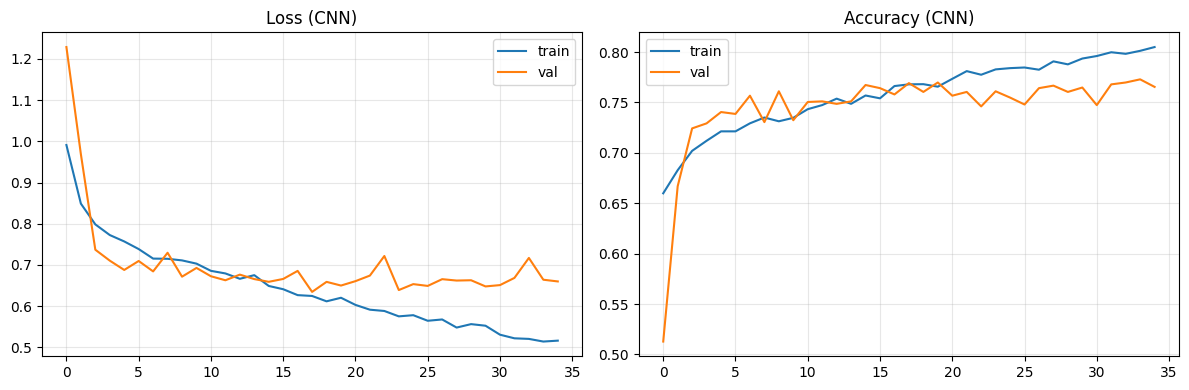

In [22]:
# Curvas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_vis_1.history['loss'], label='train')
axes[0].plot(H_vis_1.history['val_loss'], label='val')
axes[0].set_title('Loss (CNN)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(H_vis_1.history['accuracy'], label='train')
axes[1].plot(H_vis_1.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy (CNN)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## **Transfer-learning**

He hecho un modelo CNN manual para practicar y ahora, voy a pasar otros modelos de CNN (VGG16, RestNet50, InceptionV3)

### **VGG16**

In [23]:
from tensorflow.keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input

In [24]:
feature_extractor = VGG16(weights="imagenet", include_top=False)
# significa que al cargar el modelo pre-entrenado InceptionV3,
# no estamos incluyendo las capas finales de clasificación que fueron entrenadas originalmente para ImageNet.
# En su lugar, obtenemos solo la base convolucional del modelo, que se encarga de extraer características de las imágenes.
# Esto es fundamental para el aprendizaje por transferencia,

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [25]:
feature_extractor.trainable = False

In [26]:
#Definición de hiperparámetros
dropout_rate = 0.3
lr = 1e-4
epoches = 30
batch = 16

In [27]:
img_in_2 = Input(shape=(28, 28, 3))

# Aplicar la capa Resizing a la entrada
x = Resizing(224, 224)(img_in_2)

# Aplicar la capa Lambda para preprocesar la entrada de VGG16
x = Lambda(preprocess_input)(x)
# Extraer características con VGG16
image_features = feature_extractor(x, training = False)

x = GlobalAveragePooling2D()(image_features)
# Añadir capas densas para la clasificación
x = Dense(1024, activation='relu')(x)
x = Dropout(dropout_rate)(x)

x = Dense(1024, activation='relu', name="vision_features_VGG")(x)
x = Dropout(dropout_rate)(x)

img_out_2 = Dense(n_classes, activation='softmax', name='vision_output_vgg')(x)

vision_model_2 = Model(inputs=img_in_2, outputs=img_out_2)
vision_model_2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vision_features_VGG (Dense)     │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vision_output_vgg (Dense)       │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,296,775 (62.17 MB)

 Trainable params: 1,582,087 (6.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
optimizer = Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)

In [29]:
vision_model_2.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

In [30]:
H_vis_2 = vision_model_2.fit(X_img_train, Y_train, validation_data=(X_img_val, Y_val), epochs=epoches, batch_size=batch)

Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 71s 151ms/step - accuracy: 0.6675 - loss: 1.0134 - val_accuracy: 0.7342 - val_loss: 0.7537
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 131ms/step - accuracy: 0.7294 - loss: 0.7616 - val_accuracy: 0.7467 - val_loss: 0.7002
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - accuracy: 0.7504 - loss: 0.6765 - val_accuracy: 0.7580 - val_loss: 0.6595
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.7711 - loss: 0.6238 - val_accuracy: 0.7629 - val_loss: 0.6630
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 128ms/step - accuracy: 0.7848 - loss: 0.5834 - val_accuracy: 0.7561 - val_loss: 0.6443
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.7958 - loss: 0.5597 - val_accuracy: 0.7717 - val_loss: 0.6239
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.8062 - loss: 0.5165 - val_accuracy: 0.7723 - val_loss: 0.6183
Epoch 8/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.8156 - loss: 0

In [31]:
pred_2 = vision_model_2.predict(X_img_val)

51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 195ms/step


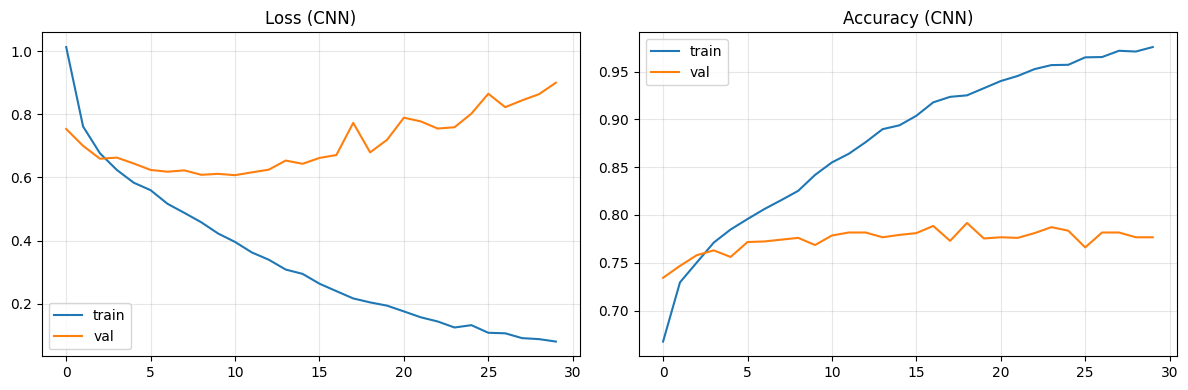

In [32]:
# Curvas train y validación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_vis_2.history['loss'], label='train')
axes[0].plot(H_vis_2.history['val_loss'], label='val')
axes[0].set_title('Loss (CNN)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(H_vis_2.history['accuracy'], label='train')
axes[1].plot(H_vis_2.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy (CNN)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

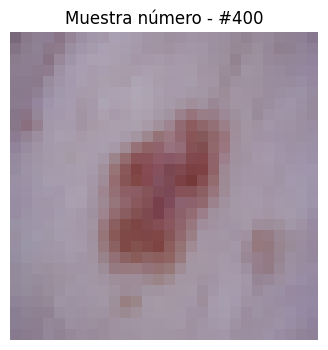

El modelo predice: nv
En realidad es:    nv


In [33]:
idx = 400
pred_probs = pred_2[idx]
pred_class_idx = np.argmax(pred_probs)
pred_class_name = classes[pred_class_idx]
true_class_idx = y_val_int[idx]
true_class_name = classes[true_class_idx]
plt.figure(figsize=(4, 4))
plt.imshow(X_img_val[idx] / 255.0)

plt.title(f"Muestra número - #{idx}")
plt.axis('off')
plt.show()

print(f"El modelo predice: {pred_class_name}")
print(f"En realidad es:    {true_class_name}")

### **Resnet**

In [34]:
from tensorflow.keras.applications import ResNet50

In [35]:
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

In [36]:
feature_extractor2 = ResNet50(weights="imagenet", include_top=False)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [37]:
feature_extractor2.trainable = False

In [38]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 30
batch = 16

In [39]:
img_in_3 = Input(shape=(28, 28, 3))

# Aplicar la capa Resizing a la entrada
x = Resizing(224, 224)(img_in_3)

# Extraer características con RestNet 50
x = Lambda(preprocess_input)(x)
image_features = feature_extractor2(x, training = False)

# Aplanar las características de RestNet 50
x = GlobalAveragePooling2D()(image_features)

# Añadir capas densas para la clasificación
x = Dense(1024, activation='relu', name = "vision_features_REST")(x)
x = Dropout(dropout_rate)(x)

img_out_3 = Dense(n_classes, activation='softmax')(x)

vision_model_3 = Model(inputs=img_in_3, outputs=img_out_3)
vision_model_3.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vision_features_REST (Dense)    │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,693,063 (98.01 MB)

 Trainable params: 2,105,351 (8.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [40]:
optimizer = Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)

In [41]:
vision_model_3.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

In [42]:
H_vis_3 = vision_model_3.fit(X_img_train, Y_train, validation_data=(X_img_val, Y_val), epochs=epoches, batch_size=batch)

Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 48s 88ms/step - accuracy: 0.6942 - loss: 0.9039 - val_accuracy: 0.7511 - val_loss: 0.6796
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.7514 - loss: 0.6895 - val_accuracy: 0.7617 - val_loss: 0.6596
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.7717 - loss: 0.6190 - val_accuracy: 0.7785 - val_loss: 0.6210
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.7864 - loss: 0.5709 - val_accuracy: 0.7735 - val_loss: 0.6162
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.8011 - loss: 0.5328 - val_accuracy: 0.7779 - val_loss: 0.5989
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.8137 - loss: 0.5075 - val_accuracy: 0.7873 - val_loss: 0.5885
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.8196 - loss: 0.4865 - val_accuracy: 0.7667 - val_loss: 0.6074
Epoch 8/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.8287 - loss: 0.4516 - 

In [43]:
pred_3 = vision_model_3.predict(X_img_val)

51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 173ms/step


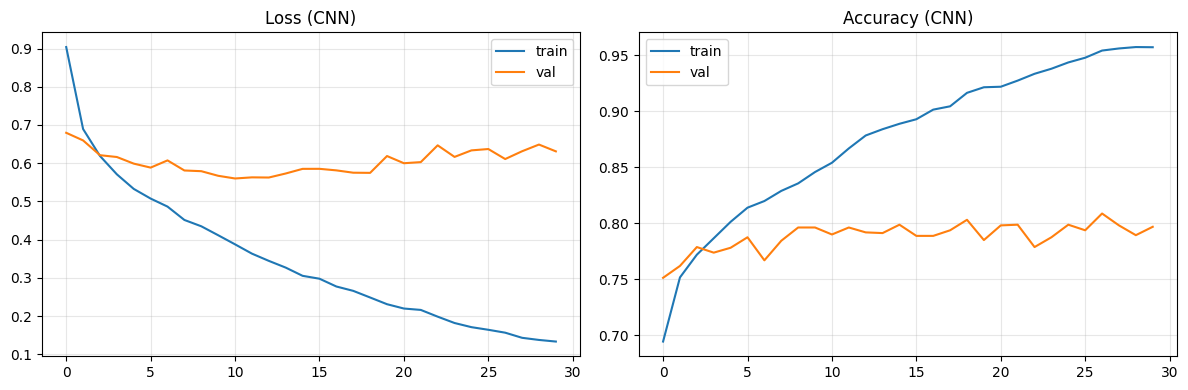

In [44]:
# Curvas train y validación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_vis_3.history['loss'], label='train')
axes[0].plot(H_vis_3.history['val_loss'], label='val')
axes[0].set_title('Loss (CNN)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(H_vis_3.history['accuracy'], label='train')
axes[1].plot(H_vis_3.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy (CNN)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

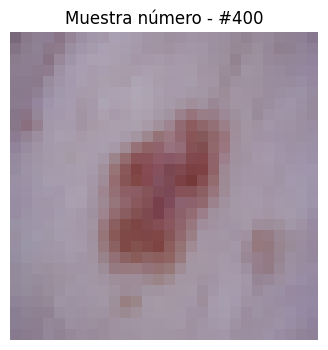

El modelo predice: nv
En realidad es:    nv


In [45]:
idx = 400
pred_probs = pred_3[idx]
pred_class_idx = np.argmax(pred_probs)
pred_class_name = classes[pred_class_idx]
true_class_idx = y_val_int[idx]
true_class_name = classes[true_class_idx]

plt.figure(figsize=(4, 4))

plt.imshow(X_img_val[idx] / 255.0)

plt.title(f"Muestra número - #{idx}")
plt.axis('off')
plt.show()

print(f"El modelo predice: {pred_class_name}")
print(f"En realidad es:    {true_class_name}")

### **Incention_v3**

In [46]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [47]:
feature_extractor3 = InceptionV3(weights="imagenet", include_top=False)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [48]:
feature_extractor3.trainable = False

In [49]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 30
batch = 16

In [50]:
img_in_4 = Input(shape=(28, 28, 3))

# Aplicar la capa Resizing a la entrada
x = Resizing(299, 299)(img_in_4)

# Extraer características con VGG16
x = Lambda(preprocess_input)(x)
image_features = feature_extractor3(x, training = False)

# Aplanar las características de VGG16
x = GlobalAveragePooling2D()(image_features)

# Añadir capas densas para la clasificación
x = Dense(1024, activation='relu', name = "vision_features_Inc")(x)
x = Dropout(dropout_rate)(x)

img_out_4 = Dense(n_classes, activation='softmax')(x)

vision_model_4 = Model(inputs=img_in_4, outputs=img_out_4)
vision_model_4.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vision_features_Inc (Dense)     │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,135 (91.20 MB)

 Trainable params: 2,105,351 (8.03 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [51]:
optimizer = Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)

In [52]:
vision_model_4.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

In [53]:
H_vis_4 = vision_model_4.fit(X_img_train, Y_train, validation_data=(X_img_val, Y_val), epochs=epoches, batch_size=batch)

Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 72s 135ms/step - accuracy: 0.6850 - loss: 0.9505 - val_accuracy: 0.7193 - val_loss: 0.8176
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.7159 - loss: 0.8056 - val_accuracy: 0.7193 - val_loss: 0.7916
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.7266 - loss: 0.7570 - val_accuracy: 0.7211 - val_loss: 0.7616
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - accuracy: 0.7435 - loss: 0.7165 - val_accuracy: 0.7218 - val_loss: 0.7562
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.7508 - loss: 0.6934 - val_accuracy: 0.7280 - val_loss: 0.7396
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.7606 - loss: 0.6586 - val_accuracy: 0.7280 - val_loss: 0.7597
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.7697 - loss: 0.6416 - val_accuracy: 0.7349 - val_loss: 0.7442
Epoch 8/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.7761 - loss: 0.6186 -

In [54]:
pred_4 = vision_model_4.predict(X_img_val)

51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 245ms/step


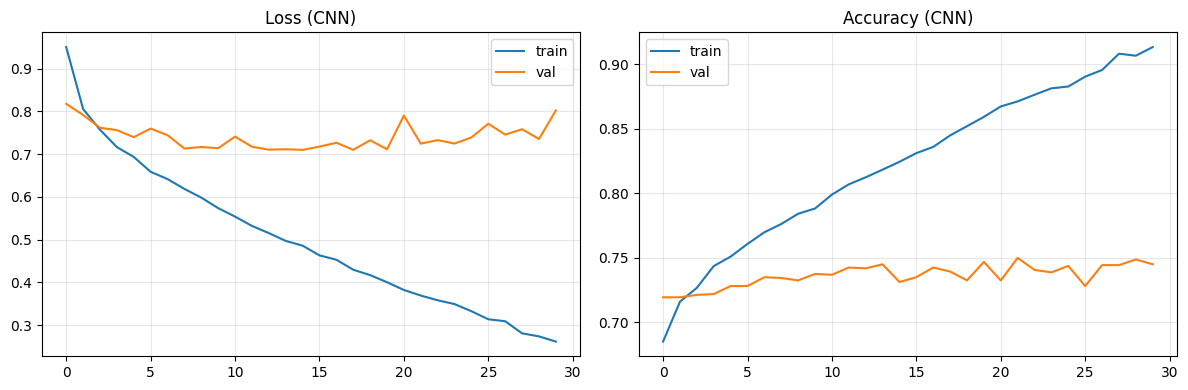

In [55]:
# Curvas train y validación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_vis_4.history['loss'], label='train')
axes[0].plot(H_vis_4.history['val_loss'], label='val')
axes[0].set_title('Loss (CNN)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(H_vis_4.history['accuracy'], label='train')
axes[1].plot(H_vis_4.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy (CNN)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

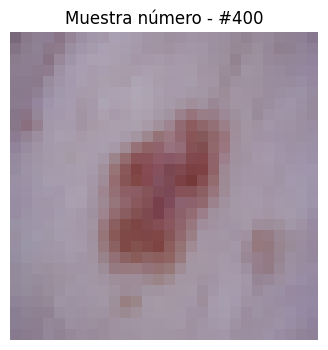

El modelo predice: nv
En realidad es:    nv


In [56]:
idx = 400
pred_probs = pred_4[idx]
pred_class_idx = np.argmax(pred_probs)
pred_class_name = classes[pred_class_idx]
true_class_idx = y_val_int[idx]
true_class_name = classes[true_class_idx]
plt.figure(figsize=(4, 4))

plt.imshow(X_img_val[idx] / 255.0)

plt.title(f"Muestra número - #{idx}")
plt.axis('off')
plt.show()

print(f"El modelo predice: {pred_class_name}")
print(f"En realidad es:    {true_class_name}")

### 3 - Estrategia late-fusion: Combinación aprendida de las predicciones realizadas por el modelo 1D y el modelo 2D desarrollados previamente para resolver el problema.

In [57]:
tabular_input_shape = (X_tab_train.shape[1],)
vision_input_shape = (28,28,3)

In [58]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 30
batch = 16

In [59]:
def build_late_fusion_model_1():
    tabular_input = Input(shape=tabular_input_shape)
    vision_input  = Input(shape=vision_input_shape)

    # Congelamos los modelos ya entrenados
    tabular_model.trainable = False
    vision_model_1.trainable = False

    # TABULAR + CNN manual
    tabular_pred = tabular_model(tabular_input)
    vision_pred_1  = vision_model_1(vision_input)

    # Fusión de las probabilidades concatenadas
    merged = Concatenate()([tabular_pred, vision_pred_1])
    output = Dense(n_classes, activation="softmax")(merged)

    # Definición final del modelo con nuevo classificador al final
    late_fusion_model_1 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return late_fusion_model_1

In [60]:
model_lf_1 = build_late_fusion_model_1()
model_lf_1.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_lf_1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 7)         │      2,615 │ input_layer_7[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 7)         │     93,511 │ input_layer_8[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 14)        │          0 │ functional[0][0], │
│ (Concatenate)       │                   │            │ functional_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 7)         │        105 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 96,231 (375.90 KB)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 96,126 (375.49 KB)

In [61]:
H_lf_1 = model_lf_1.fit([X_tab_train, X_img_train], Y_train,validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size= batch)

Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0552 - loss: 2.0709 - val_accuracy: 0.0618 - val_loss: 2.0108
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0610 - loss: 1.9447 - val_accuracy: 0.0792 - val_loss: 1.8897
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1095 - loss: 1.8253 - val_accuracy: 0.2364 - val_loss: 1.7770
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6017 - loss: 1.7149 - val_accuracy: 0.6563 - val_loss: 1.6720
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6705 - loss: 1.6117 - val_accuracy: 0.6800 - val_loss: 1.5754
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6833 - loss: 1.5163 - val_accuracy: 0.6794 - val_loss: 1.4871
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6814 - loss: 1.4304 - val_accuracy: 0.6750 - val_loss: 1.4068
Epoch 8/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6778 - loss: 1.3535 - val_accuracy: 0.

In [62]:
pred_lf_1 = model_lf_1.predict([X_tab_val, X_img_val])

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [63]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 30
batch = 16

In [64]:
def build_late_fusion_model_2():
    tabular_input = Input(shape=tabular_input_shape)
    vision_input  = Input(shape=vision_input_shape)

    tabular_model.trainable = False
    vision_model_2.trainable = False

    # TABULAR + VGG16
    tabular_pred = tabular_model(tabular_input)
    vision_pred_2  = vision_model_2(vision_input)

    # Fusión de las probabilidades concatenadas
    merged = Concatenate()([tabular_pred, vision_pred_2])
    output = Dense(n_classes, activation="softmax")(merged)

    # Definición final del modelo con nuevo classificador al final
    late_fusion_model_2 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return late_fusion_model_2

In [65]:
model_lf_2 = build_late_fusion_model_2()
model_lf_2.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_lf_2.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 7)         │      2,615 │ input_layer_9[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_2        │ (None, 7)         │ 16,296,775 │ input_layer_10[0… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 14)        │          0 │ functional[1][0], │
│ (Concatenate)       │                   │            │ functional_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 7)         │        105 │ concatenate_3[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,299,495 (62.18 MB)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 16,299,390 (62.18 MB)

In [ ]:
H_lf_2 = model_lf_2.fit([X_tab_train, X_img_train], Y_train,validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size= batch)

Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 61s 144ms/step - accuracy: 0.0281 - loss: 2.1061 - val_accuracy: 0.0399 - val_loss: 2.0313
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.0735 - loss: 1.9658 - val_accuracy: 0.1179 - val_loss: 1.9057
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - accuracy: 0.2267 - loss: 1.8342 - val_accuracy: 0.4074 - val_loss: 1.7883
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - accuracy: 0.6389 - loss: 1.7105 - val_accuracy: 0.6263 - val_loss: 1.6790
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.6764 - loss: 1.5942 - val_accuracy: 0.6307 - val_loss: 1.5783
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.6787 - loss: 1.4863 - val_accuracy: 0.6425 - val_loss: 1.4860
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.6756 - loss: 1.3886 - val_accuracy: 0.6532 - val_loss: 1.4020
Epoch 8/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - accuracy: 0.6747 - loss: 1

In [ ]:
pred_lf_2 = model_lf_2.predict([X_tab_val, X_img_val])

In [ ]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 30
batch = 16

In [ ]:
def build_late_fusion_model_3():
    tabular_input = Input(shape=tabular_input_shape)
    vision_input  = Input(shape=vision_input_shape)

    tabular_model.trainable = False
    vision_model_3.trainable = False

    # TABULAR + RESNET
    tabular_pred = tabular_model(tabular_input)
    vision_pred_3  = vision_model_3(vision_input)

    # Fusión de las probabilidades concatenadas
    merged = Concatenate()([tabular_pred, vision_pred_3])
    output = Dense(n_classes, activation="softmax")(merged)

    # Definición final del modelo con nuevo classificador al final
    late_fusion_model_3 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return late_fusion_model_3

In [ ]:
model_lf_3 = build_late_fusion_model_3()
model_lf_3.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_lf_3.summary()

In [ ]:
H_lf_3 = model_lf_3.fit([X_tab_train, X_img_train], Y_train,validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size= batch)

In [ ]:
pred_lf_3 = model_lf_3.predict([X_tab_val, X_img_val])

In [ ]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 30
batch = 16

In [ ]:
def build_late_fusion_model_4():
    tabular_input = Input(shape=tabular_input_shape)
    vision_input  = Input(shape=vision_input_shape)

    tabular_model.trainable = False
    vision_model_4.trainable = False

    # TABULAR + INCEPTION
    tabular_pred = tabular_model(tabular_input)
    vision_pred_4  = vision_model_4(vision_input)

    # Fusión de las probabilidades concatenadas
    merged = Concatenate()([tabular_pred, vision_pred_4])
    output = Dense(n_classes, activation="softmax")(merged)

    # Definición final del modelo con nuevo classificador al final
    late_fusion_model_4 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return late_fusion_model_4

In [ ]:
model_lf_4 = build_late_fusion_model_4()
model_lf_4.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_lf_4.summary()

In [ ]:
H_lf_4 = model_lf_4.fit([X_tab_train, X_img_train], Y_train,validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size= batch)

In [ ]:
pred_lf_4 = model_lf_4.predict([X_tab_val, X_img_val])

### 4 - Estrategia early-fusion: Combinación aprendida de las características realizadas por el modelo 1D y el modelo 2D desarrollados previamente para resolver el problema.

In [ ]:
tabular_input_shape = (X_tab_train.shape[1],)
vision_input_shape = (28,28,3)

In [ ]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 30
batch = 16

In [ ]:
def build_early_fusion_model_1():
    # Inputs
    tabular_input = Input(shape=tabular_input_shape)
    vision_input = Input(shape=vision_input_shape, name="vision_input")

    # TABULAR + CNN manual
    tabular_intermediate = Model(inputs=tabular_model.input, outputs=tabular_model.get_layer('tabular_features').output)
    vision_intermediate = Model(inputs=vision_model_1.input, outputs=vision_model_1.get_layer('vision_features').output)

    tabular_model.trainable = False
    vision_model_1.trainable = False

    tabular_features = tabular_intermediate(tabular_input)
    vision_features = vision_intermediate(vision_input)

    # Fusionamos la representación de ambas modalidades
    merged = Concatenate()([tabular_features, vision_features])

    # Añadimos un clasificador, que suele ser más complejo que en late-fusion
    x = Dense(128, activation="relu")(merged)
    x = Dense(64, activation="relu")(x)
    output = Dense(n_classes, activation="softmax", name="final_output")(x)

    early_fusion_model_1 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return early_fusion_model_1

In [ ]:
model_ef_1 = build_early_fusion_model_1()
model_ef_1.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_ef_1.summary()

In [ ]:
H_ef_1 = model_ef_1.fit([X_tab_train, X_img_train], Y_train, validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size=batch)

In [ ]:
pred_ef_1 = model_ef_1.predict([X_tab_val, X_img_val])

In [ ]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 30
batch = 16

In [ ]:
def build_early_fusion_model_2():
    # Inputs
    tabular_input = Input(shape=tabular_input_shape, name="tabular_input")
    vision_input = Input(shape=vision_input_shape, name="vision_input")

    tabular_model.trainable = False
    vision_model_2.trainable = False

    # TABULAR + VGG16
    tabular_intermediate = Model(inputs=tabular_model.input, outputs=tabular_model.get_layer('tabular_features').output)
    vision_intermediate = Model(inputs=vision_model_2.input, outputs=vision_model_2.get_layer("vision_features_VGG").output)

    tabular_features = tabular_intermediate(tabular_input)
    vision_features = vision_intermediate(vision_input)

    # Fusionamos la representación de ambas modalidades
    merged = Concatenate()([tabular_features, vision_features])

    # Añadimos un clasificador, que suele ser más complejo que en late-fusion
    x = Dense(128, activation="relu")(merged)
    x = Dense(64, activation="relu")(x)
    output = Dense(n_classes, activation="softmax", name="final_output")(x)

    early_fusion_model_2 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return early_fusion_model_2

In [ ]:
model_ef_2 = build_early_fusion_model_2()
model_ef_2.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_ef_2.summary()

In [ ]:
H_ef_2 = model_ef_2.fit([X_tab_train, X_img_train], Y_train, validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size=batch)

In [ ]:
pred_ef_2 = model_ef_2.predict([X_tab_val, X_img_val])

In [ ]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 30
batch = 16

In [ ]:
def build_early_fusion_model_3():
    # Inputs
    tabular_input = Input(shape=tabular_input_shape, name="tabular_input")
    vision_input = Input(shape=vision_input_shape, name="vision_input")

    tabular_model.trainable = False
    vision_model_3.trainable = False

    # TABULAR + RESNET
    tabular_intermediate = Model(inputs=tabular_model.input, outputs=tabular_model.get_layer('tabular_features').output)
    vision_intermediate = Model(inputs=vision_model_3.input, outputs=vision_model_3.get_layer("vision_features_REST").output)

    tabular_features = tabular_intermediate(tabular_input)
    vision_features = vision_intermediate(vision_input)

    # Fusionamos la representación de ambas modalidades
    merged = Concatenate()([tabular_features, vision_features])

    # Añadimos un clasificador, que suele ser más complejo que en late-fusion
    x = Dense(128, activation="relu")(merged)
    x = Dense(64, activation="relu")(x)
    output = Dense(n_classes, activation="softmax", name="final_output")(x)

    early_fusion_model_3 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return early_fusion_model_3

In [ ]:
model_ef_3 = build_early_fusion_model_3()
model_ef_3.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_ef_3.summary()

In [ ]:
H_ef_3 = model_ef_3.fit([X_tab_train, X_img_train], Y_train, validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size=batch)

In [ ]:
pred_ef_3 = model_ef_3.predict([X_tab_val, X_img_val])

In [ ]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 30
batch = 16

In [ ]:
def build_early_fusion_model_4():
    # Inputs
    tabular_input = Input(shape=tabular_input_shape, name="tabular_input")
    vision_input = Input(shape=vision_input_shape, name="vision_input")

    tabular_model.trainable = False
    vision_model_4.trainable = False

    # TABULAR + Inception
    tabular_intermediate = Model(inputs=tabular_model.input, outputs=tabular_model.get_layer('tabular_features').output)
    vision_intermediate = Model(inputs=vision_model_4.input, outputs=vision_model_4.get_layer("vision_features_Inc").output)

    tabular_features = tabular_intermediate(tabular_input)
    vision_features = vision_intermediate(vision_input)

    # Fusionamos la representación de ambas modalidades
    merged = Concatenate()([tabular_features, vision_features])

    # Añadimos un clasificador, que suele ser más complejo que en late-fusion
    x = Dense(128, activation="relu")(merged)
    x = Dense(64, activation="relu")(x)
    output = Dense(n_classes, activation="softmax", name="final_output")(x)

    early_fusion_model_4 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return early_fusion_model_4

In [ ]:
model_ef_4 = build_early_fusion_model_4()
model_ef_4.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_ef_4.summary()

In [ ]:
H_ef_4 = model_ef_4.fit([X_tab_train, X_img_train], Y_train, validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size=batch)

In [ ]:
pred_ef_4 = model_ef_4.predict([X_tab_val, X_img_val])

In [ ]:
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, confusion_matrix)
import seaborn as sns

def eval_modelo(model, X_input, y_true_int, nombre):
    pred = model.predict(X_input, verbose=0)
    y_pred = pred.argmax(axis=1)
    acc = accuracy_score(y_true_int, y_pred)
    f1  = f1_score(y_true_int, y_pred, average='macro')
    print(f'\n━━━ {nombre} ━━━')
    print(f'Accuracy: {acc:.4f} | F1-macro: {f1:.4f}')
    print(classification_report(y_true_int, y_pred,
                                target_names=classes, zero_division=0))
    return {'nombre': nombre, 'acc': acc, 'f1': f1, 'y_pred': y_pred}

resultados = []
resultados.append(eval_modelo(tabular_model,  X_tab_test, y_test_int, 'H1 - Tabular'))
resultados.append(eval_modelo(vision_model_1, X_img_test, y_test_int, 'H2 - CNN manual'))
resultados.append(eval_modelo(vision_model_2, X_img_test, y_test_int, 'H2 - VGG16'))
resultados.append(eval_modelo(vision_model_3, X_img_test, y_test_int, 'H2 - ResNet50'))
resultados.append(eval_modelo(vision_model_4, X_img_test, y_test_int, 'H2 - InceptionV3'))
resultados.append(eval_modelo(model_lf_1, [X_tab_test, X_img_test], y_test_int, 'H3 - LF CNN'))
resultados.append(eval_modelo(model_lf_2, [X_tab_test, X_img_test], y_test_int, 'H3 - LF VGG'))
resultados.append(eval_modelo(model_lf_3, [X_tab_test, X_img_test], y_test_int, 'H3 - LF ResNet'))
resultados.append(eval_modelo(model_lf_4, [X_tab_test, X_img_test], y_test_int, 'H3 - LF Inception'))
resultados.append(eval_modelo(model_ef_1, [X_tab_test, X_img_test], y_test_int, 'H4 - EF CNN'))
resultados.append(eval_modelo(model_ef_2, [X_tab_test, X_img_test], y_test_int, 'H4 - EF VGG'))
resultados.append(eval_modelo(model_ef_3, [X_tab_test, X_img_test], y_test_int, 'H4 - EF ResNet'))
resultados.append(eval_modelo(model_ef_4, [X_tab_test, X_img_test], y_test_int, 'H4 - EF Inception'))

resumen = pd.DataFrame(
    [(r['nombre'], r['acc'], r['f1']) for r in resultados],
    columns=['Modelo', 'Accuracy', 'F1-macro']
).sort_values('F1-macro', ascending=False).reset_index(drop=True)
print('\n\n══════ TABLA COMPARATIVA ══════')
print(resumen.to_string(index=False))

mejor = max(resultados, key=lambda r: r['f1'])
cm = confusion_matrix(y_test_int, mejor['y_pred'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes,
            yticklabels=classes, cmap='Blues')
plt.title(f"Matriz de confusión - {mejor['nombre']}")
plt.ylabel('Verdadero'); plt.xlabel('Predicho')
plt.tight_layout()
plt.show()